In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
pd.set_option('display.max_columns', None)

DATA_DIR = Path("../data/raw")

train = pd.read_csv(DATA_DIR / "train.csv")

target = "SalePrice"
id_col = "Id"

print(train.shape)
display(train.head())


(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
saleprice_summary = train[target].describe()
saleprice_skew = train[target].skew()
log_saleprice_skew = np.log1p(train[target]).skew()

display(saleprice_summary)
print("SalePrice skewness:", saleprice_skew)
print("log1p(SalePrice) skewness:", log_saleprice_skew)

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

SalePrice skewness: 1.8828757597682129
log1p(SalePrice) skewness: 0.12134661989685333


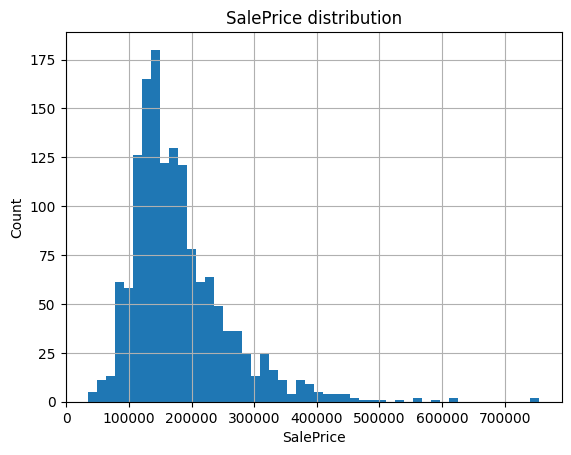

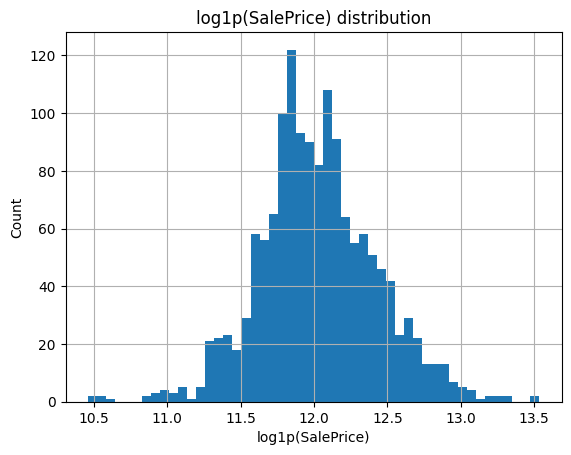

In [4]:
train[target].hist(bins=50)
plt.title("SalePrice distribution")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

np.log1p(train[target]).hist(bins=50)
plt.title("log1p(SalePrice) distribution")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Count")
plt.show()

In [5]:
feature_cols = [col for col in train.columns if col not in [target, id_col]]

numeric_features = train[feature_cols].select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = train[feature_cols].select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 36
Categorical features: 43


C:\Users\Александр\AppData\Local\Temp\ipykernel_3100\2443922907.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train[feature_cols].select_dtypes(include=["object"]).columns.tolist()


In [6]:
missing = (
    train.isna()
    .sum()
    .to_frame("missing_count")
)

missing["missing_pct"] = missing["missing_count"] / len(train) * 100
missing = missing[missing["missing_count"] > 0].sort_values("missing_count", ascending=False)

display(missing)

,missing_count,missing_pct
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [7]:
absence_missing_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "GarageYrBlt",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
]

unknown_missing_cols = [
    "LotFrontage",
    "MasVnrType",
    "MasVnrArea",
    "Electrical",
]

print("Likely absence missingness:", absence_missing_cols)
print("Likely unknown missingness:", unknown_missing_cols)

Likely absence missingness: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageYrBlt', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
Likely unknown missingness: ['LotFrontage', 'MasVnrType', 'MasVnrArea', 'Electrical']


In [8]:
numeric_corr = (
    train[numeric_features + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

display(numeric_corr.head(20))
display(numeric_corr.tail(10))

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
LotArea         0.263843
Name: SalePrice, dtype: float64

PoolArea        0.092404
MSSubClass     -0.084284
OverallCond    -0.077856
MoSold          0.046432
3SsnPorch       0.044584
YrSold         -0.028923
LowQualFinSF   -0.025606
MiscVal        -0.021190
BsmtHalfBath   -0.016844
BsmtFinSF2     -0.011378
Name: SalePrice, dtype: float64

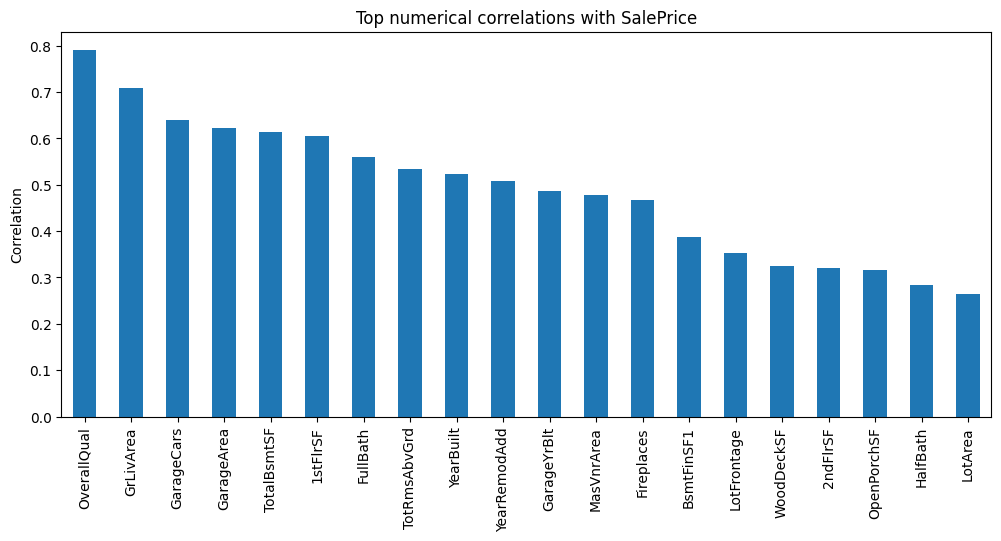

In [9]:
numeric_corr.head(20).plot(kind="bar", figsize=(12, 5))
plt.title("Top numerical correlations with SalePrice")
plt.ylabel("Correlation")
plt.show()

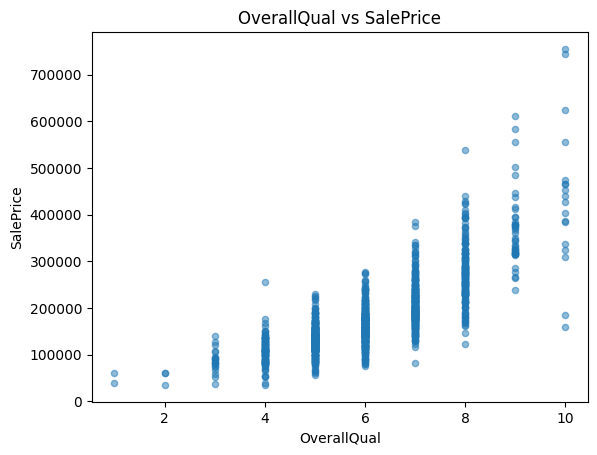

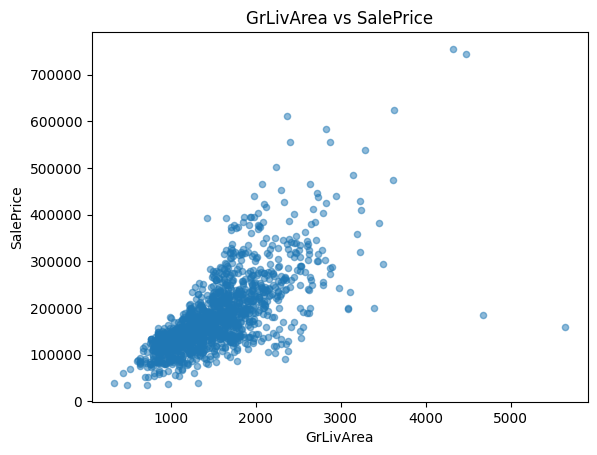

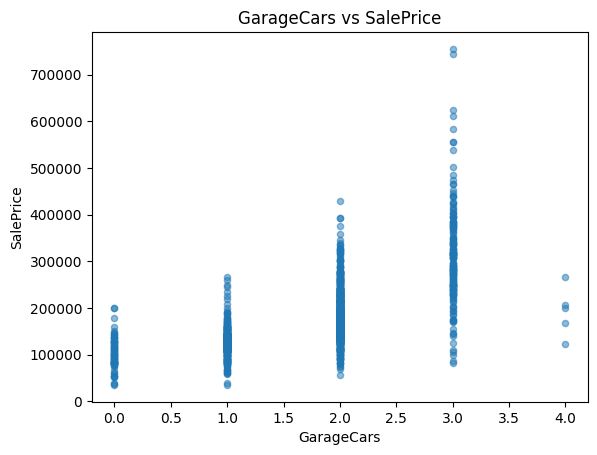

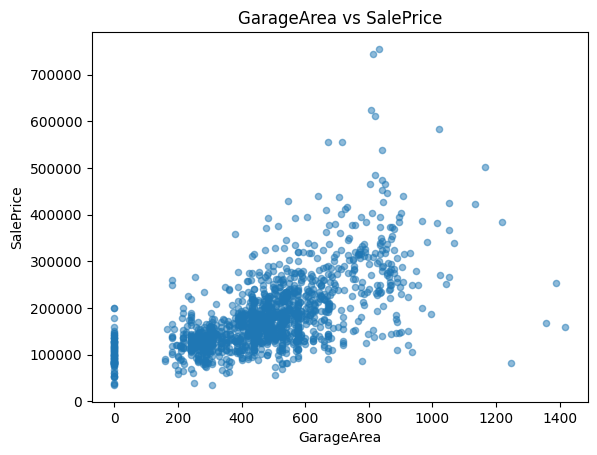

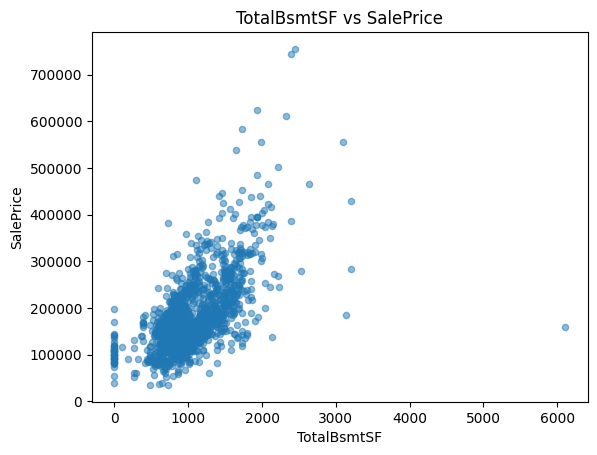

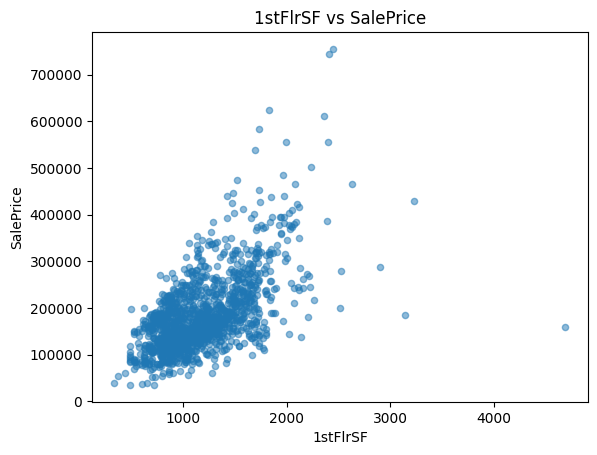

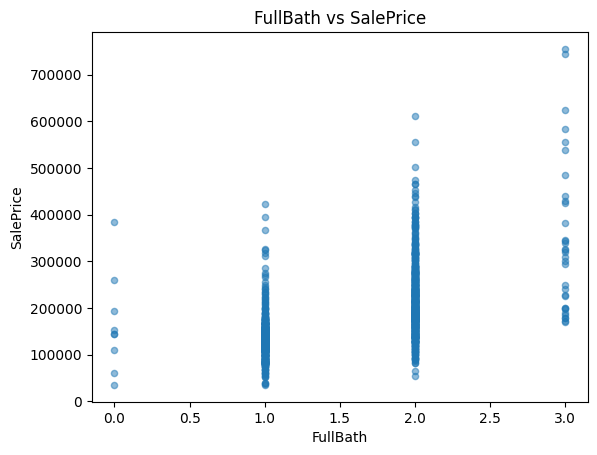

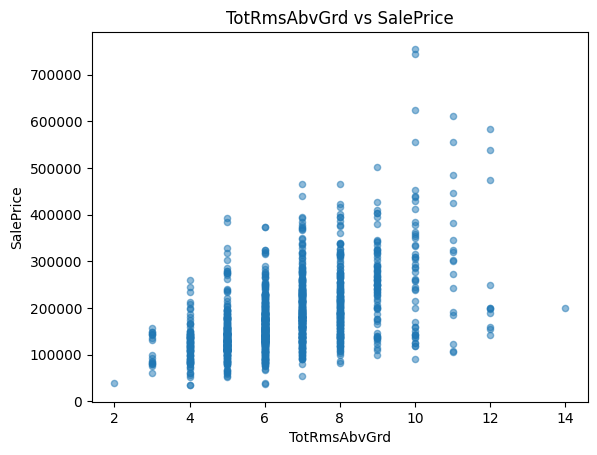

In [10]:
top_numeric_for_scatter = numeric_corr.head(8).index.tolist()

for col in top_numeric_for_scatter:
    train.plot.scatter(x=col, y=target, alpha=0.5)
    plt.title(f"{col} vs {target}")
    plt.show()

In [15]:
cat_summary = pd.DataFrame({
    "n_unique": train[categorical_features].nunique(dropna=False),
    "missing_count": train[categorical_features].isna().sum(),
})

cat_summary["missing_pct"] = cat_summary["missing_count"] / len(train) * 100
cat_summary = cat_summary.sort_values(["n_unique"], ascending=False)

display(cat_summary)

,n_unique,missing_count,missing_pct
Neighborhood,25,0,0.000000
Exterior2nd,16,0,0.000000
Exterior1st,15,0,0.000000
Condition1,9,0,0.000000
SaleType,9,0,0.000000
HouseStyle,8,0,0.000000
RoofMatl,8,0,0.000000
Condition2,8,0,0.000000
BsmtFinType2,7,38,2.602740
BsmtFinType1,7,37,2.534247


In [12]:
for col in categorical_features:
    summary = (
        train.groupby(col, dropna=False)[target]
        .agg(["count", "median", "mean"])
        .sort_values("median", ascending=False)
    )
    
    print(f"\n=== {col} ===")
    display(summary)


=== MSZoning ===


,count,median,mean
MSZoning,,,
FV,65,205950.0,214014.061538
RL,1151,174000.0,191004.994787
RH,16,136500.0,131558.375000
RM,218,120500.0,126316.830275
C (all),10,74700.0,74528.000000



=== Street ===


,count,median,mean
Street,,,
Pave,1454,163000.0,181130.538514
Grvl,6,114250.0,130190.500000



=== Alley ===


...

,count,median,mean
MiscFeature,,,
TenC,1,250000.0,250000.000000
Gar2,2,170750.0,170750.000000
NaN,1406,164250.0,182046.410384
Shed,49,144000.0,151187.612245
Othr,2,94000.0,94000.000000



=== SaleType ===


,count,median,mean
SaleType,,,
Con,2,269600.0,269600.000000
New,122,247453.0,274945.418033
CWD,4,188750.0,210600.000000
WD,1267,158000.0,173401.836622
ConLw,5,144000.0,143700.000000
ConLD,9,140000.0,138780.888889
COD,43,139000.0,143973.255814
ConLI,5,125000.0,200390.000000
Oth,3,116050.0,119850.000000



=== SaleCondition ===


,count,median,mean
SaleCondition,,,
Partial,125,244600.0,272291.752000
Normal,1198,160000.0,175202.219533
Alloca,12,148145.0,167377.416667
Family,20,140500.0,149600.000000
Abnorml,101,130000.0,146526.623762
AdjLand,4,104000.0,104125.000000


In [13]:
important_cat_cols = [
    "Neighborhood",
    "ExterQual",
    "KitchenQual",
    "BsmtQual",
    "GarageType",
    "GarageFinish",
    "FireplaceQu",
    "MSZoning",
    "HouseStyle",
    "SaleCondition",
]

for col in important_cat_cols:
    summary = (
        train.groupby(col, dropna=False)[target]
        .agg(["count", "median", "mean"])
        .sort_values("median", ascending=False)
    )
    
    print(f"\n=== {col} ===")
    display(summary)


=== Neighborhood ===


,count,median,mean
Neighborhood,,,
NridgHt,77,315000.0,316270.623377
NoRidge,41,301500.0,335295.317073
StoneBr,25,278000.0,310499.000000
Timber,38,228475.0,242247.447368
Somerst,86,225500.0,225379.837209
Veenker,11,218000.0,238772.727273
Crawfor,51,200624.0,210624.725490
ClearCr,28,200250.0,212565.428571
CollgCr,150,197200.0,197965.773333



=== ExterQual ===


,count,median,mean
ExterQual,,,
Ex,52,364606.5,367360.961538
Gd,488,220000.0,231633.510246
TA,906,139450.0,144341.313466
Fa,14,82250.0,87985.214286



=== KitchenQual ===


...

,count,median,mean
MSZoning,,,
FV,65,205950.0,214014.061538
RL,1151,174000.0,191004.994787
RH,16,136500.0,131558.375000
RM,218,120500.0,126316.830275
C (all),10,74700.0,74528.000000



=== HouseStyle ===


,count,median,mean
HouseStyle,,,
2.5Fin,8,194000.0,220000.000000
2Story,445,190000.0,210051.764045
SLvl,65,164500.0,166703.384615
1Story,726,154750.0,175985.477961
SFoyer,37,135960.0,135074.486486
2.5Unf,11,133900.0,157354.545455
1.5Fin,154,132000.0,143116.740260
1.5Unf,14,111250.0,110150.000000



=== SaleCondition ===


,count,median,mean
SaleCondition,,,
Partial,125,244600.0,272291.752000
Normal,1198,160000.0,175202.219533
Alloca,12,148145.0,167377.416667
Family,20,140500.0,149600.000000
Abnorml,101,130000.0,146526.623762
AdjLand,4,104000.0,104125.000000


## Stage 2 EDA conclusions

### Target
- SalePrice is right-skewed.
- log1p(SalePrice) is more symmetric.
- Later modeling may benefit from log target transformation, but this must be handled CV-safely.

### Missing values
- Several categorical missing values likely mean absence of a property, e.g. no pool, no alley access, no fence, no fireplace, no garage, no basement.
- Some missing values are more likely unknown/missing measurements, e.g. LotFrontage, MasVnrArea, Electrical.
- Imputation must be done inside Pipeline / ColumnTransformer later.

### Numerical features
- Strong candidates to inspect: OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, 1stFlrSF, FullBath, YearBuilt.
- Possible outliers should be reviewed, especially large GrLivArea with relatively low SalePrice.

### Categorical features
- Neighborhood, quality-related columns, basement/garage/fireplace-related columns likely contain useful signal.
- OneHotEncoder is appropriate for baseline preprocessing.
- High-cardinality categorical features should be monitored.

### Leakage risks
- Id should be excluded from meaningful features.
- Official Kaggle test.csv must not be used for validation.
- No preprocessing should be fitted before split.
- No target-dependent encoding or feature engineering should be fitted outside CV.
- Train and official test should not be combined for fitted preprocessing during local validation.

### Preprocessing hypotheses
- Numeric features: SimpleImputer, possibly median strategy.
- Categorical unknown missingness: SimpleImputer with most_frequent or constant.
- Categorical absence missingness: likely fill with "None" inside pipeline.
- Categorical encoding: OneHotEncoder(handle_unknown="ignore").
- Target: compare raw SalePrice vs log1p target later using CV-safe approach.

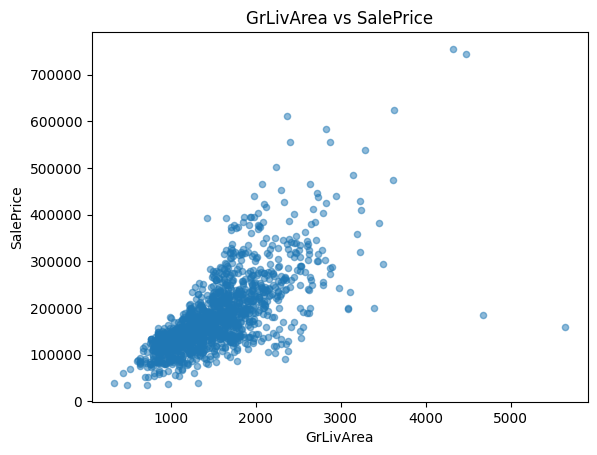

In [16]:
train.plot.scatter(x="GrLivArea", y="SalePrice", alpha=0.5)
plt.title("GrLivArea vs SalePrice")
plt.show()

In [17]:
train[["Id", "GrLivArea", "SalePrice"]].sort_values("GrLivArea", ascending=False).head(10)

,Id,GrLivArea,SalePrice
1298,1299,5642,160000
523,524,4676,184750
1182,1183,4476,745000
691,692,4316,755000
1169,1170,3627,625000
185,186,3608,475000
304,305,3493,295000
1268,1269,3447,381000
635,636,3395,200000
769,770,3279,538000


Potential outliers:
- Id 1299: very high GrLivArea = 5642, but SalePrice = 160000.
- Id 524: very high GrLivArea = 4676, but SalePrice = 184750.
- These rows should not be removed during EDA. They are flagged for later experiments after baseline and validation design.